In this notebook, we'll explore clustering of the articles by their text.

The goal is to obtain separate clusters belonging to specific topics.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sentence_transformers import SentenceTransformer
import umap
import hdbscan
from stop_words import get_stop_words
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
import scipy.sparse as sp

from bertopic import BERTopic

In [2]:
REPO_PATH = "../.."

# Data preprocessing

We'll use an already scraped dataset that was obtained using different search terms.

This way we can see if our clustering ends up similar to the search terms.

In [3]:
dataset = "HOT_TOPICS-20240929000000"

In [4]:
folder = Path(f"{REPO_PATH}/data/scrapes/{dataset}/articles")
docs = [p.read_text(encoding="utf-8") for p in folder.glob("*.txt")]
filenames = [p.name for p in folder.glob("*.txt")]

In [5]:
articles = pd.read_csv(f"{REPO_PATH}/data/scrapes/{dataset}/articles.csv")

## Text Embeddings

To be able to cluster out articles, we'll transform them into text embeddings.

We'll choose a Sentence Transformers model: `all-MiniLM-L6-v2`

<div style="background-color: blue; color: white; padding: 10px; border-radius: 5px;">

Why embeddings instead of TF-IDF?

They capture semantics (synonyms, paraphrases) so articles about “inflation” and “cost of living” land near each other even if they share few exact words.

</div>

In [6]:
from sentence_transformers import SentenceTransformer

model  = SentenceTransformer("all-MiniLM-L6-v2")   # ~40 MB download

In [7]:
embeddings = model.encode(docs, show_progress_bar=True, batch_size=32)

Batches: 100%|██████████| 16/16 [00:03<00:00,  4.69it/s]


## Dimensionality Reduction

UMAP squeezes 384 → 5–50 dimensions, which reduces noise and speeds clustering.

In [8]:
umap_model = umap.UMAP(n_neighbors=15, n_components=15, metric="cosine", random_state=42)

In [9]:
embeddings_umap = umap_model.fit_transform(embeddings)

# Clustering

First we define the stopwords for later.

In [ ]:
stop_ca = get_stop_words('ca')
extra = ["del", "dels", "al", "als", "li", "per", "amb", "hi", "ha", "han",
         "ho", "pel", "no", "ni", "hem", "més", "ni", "què", "ja", "se", "sí",
         "són", "des"]
stop_ca = stop_ca + extra

## With HDBSCAN

HDBSCAN finds a sensible number of clusters automatically and can mark “miscellaneous” documents as noise (label = -1).

In [10]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=8,           # tune ≥ 5 % of corpus size
                            min_samples=2,                # how strict to be
                            metric="euclidean",           # euclidean on UMAP output
                            cluster_selection_method="eom").fit(embeddings_umap)

labels = clusterer.labels_          # array length 488
n_clusters = len(set(labels)) - (-1 in labels)
print(f"{n_clusters} clusters found ({(labels==-1).sum()} noise docs).")


21 clusters found (143 noise docs).


### Naming the clusters

In [30]:
df = pd.DataFrame({"doc": docs, "label": labels})

topic_words = {}
for label, group in df.groupby("label"):
    if label == -1:            # skip noise
        continue
    corpus = group["doc"].values
    cv     = CountVectorizer(max_df=0.8, stop_words=stop_ca, ngram_range=(1,3))
    X      = cv.fit_transform(corpus)

    # ----- REPLACE the next two original lines with the three below -----
    term_counts = sp.csr_matrix(X.sum(axis=0))                  # 1 × N sparse row
    tfidf_row   = TfidfTransformer(use_idf=True).fit_transform(term_counts)
    top_ix      = tfidf_row.toarray().ravel().argsort()[-10:][::-1]
    # --------------------------------------------------------------------

    topic_words[label] = [cv.get_feature_names_out()[i] for i in top_ix]

# quick peek
for label, words in topic_words.items():
    print(label, "→", ", ".join(words))

0 → curs, escola, andorra, alumnes, educació, estimar, activitats, persones, andorrana, cobrir
1 → andorra, dones, aquest, igualtat, dos, col, cap, espot, gestió, any
2 → ipc, mes, preus, agost, dècimes, variació, inflació, avançat, habitatge, disminució
3 → dones, andorra, avortament, cass, aquest, drets, fins, campanya, social, govern
4 → aquest, llei, institut, comuns, mesures, nou, aquesta, fet, general, consell
5 → europa, creixement, aquest, any, economia, andorra, mesos, mercat, vendes, inversió
6 → habitatge, lloguer, sobre, aquesta, casos, propietaris, anys, així, andorra, col
7 → aquest, obres, acord, projecte, cass, anys, fins, sobre, informació, habitatge
8 → euros, milions, respecte, 2023, anterior, semestre, persones, mateix, milions euros, mes
9 → comú, govern, centre, milions, edifici, pisos, sant, euros, projecte, nou
10 → aquest, govern, país, sobre, seva, acord, general, cap, aquesta, països
11 → acord, habitatge, llei, síndic, sobre, ensenyat, govern, fet, concòrdia

In [45]:
cluster_names = {
    lbl: "_".join(words[:3])          # keep 2-3 strongest terms
    for lbl, words in topic_words.items()
}
cluster_names[-1] = "Altres"      # noise/outliers

In [46]:
df["cluster_name"] = df["label"].map(cluster_names)

### Visualizing the clusters

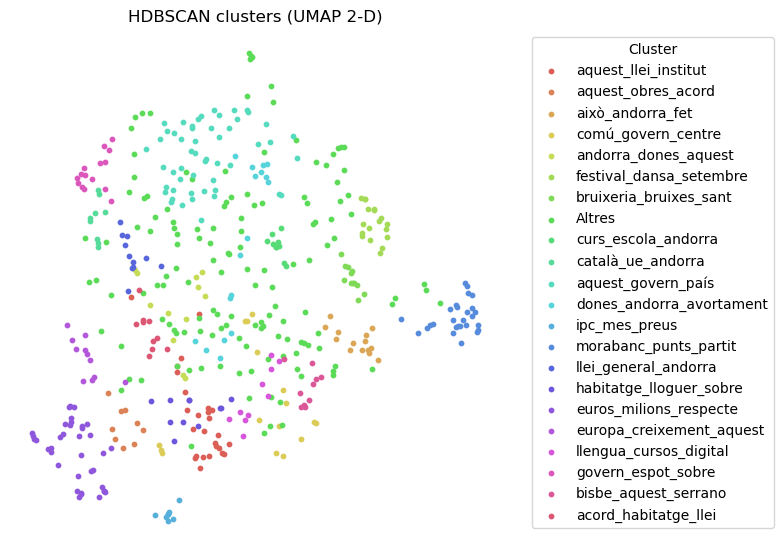

In [49]:
# --- 2-D projection (same as before) ------------------------------------
reducer = umap.UMAP(n_neighbors=15, n_components=2,
                    metric="cosine", random_state=42)
emb2d   = reducer.fit_transform(embeddings)

# --- names & palette ----------------------------------------------------
names         = df["cluster_name"].fillna("Un-named").values
unique_names  = pd.unique(names)                     # preserves order
palette       = {n: sns.color_palette("hls", len(unique_names))[i]
                 for i, n in enumerate(unique_names)}

# --- scatter ------------------------------------------------------------
plt.figure(figsize=(8, 6))
for name in unique_names:
    idx = names == name
    plt.scatter(emb2d[idx, 0], emb2d[idx, 1],
                s=10, c=[palette[name]], label=name)

plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("HDBSCAN clusters (UMAP 2-D)")
plt.axis("off")          # optional
plt.tight_layout()
plt.show()


### Article counts per topic

In [51]:
hdb_counts = (
    df.groupby("cluster_name").size()
      .sort_values(ascending=False)
      .rename("Articles")
)
print(hdb_counts)

cluster_name
Altres                      143
aquest_govern_país           52
euros_milions_respecte       37
morabanc_punts_partit        27
aquest_llei_institut         26
festival_dansa_setembre      18
dones_andorra_avortament     17
comú_govern_centre           16
govern_espot_sobre           15
això_andorra_fet             14
andorra_dones_aquest         12
bruixeria_bruixes_sant       12
llei_general_andorra         11
habitatge_lloguer_sobre      11
europa_creixement_aquest     11
acord_habitatge_llei         10
bisbe_aquest_serrano         10
llengua_cursos_digital       10
curs_escola_andorra          10
català_ue_andorra             9
aquest_obres_acord            9
ipc_mes_preus                 8
Name: Articles, dtype: int64


## With BERT Topic

In [52]:
vectorizer = CountVectorizer(
                stop_words=stop_ca,
                max_df=0.8,
                ngram_range=(1, 3))

topic_model = BERTopic(
                language="multilingual",       # keep the embedding model you like
                vectorizer_model=vectorizer,   # ← custom vectorizer
                min_topic_size=8,
                calculate_probabilities=True)

In [53]:
topics, probs = topic_model.fit_transform(docs)

### Naming the clusters

In [60]:
topic_info = topic_model.get_topic_info()
print(topic_info[["Topic", "Name", "Count"]].head(20))

    Topic                                           Name  Count
0      -1               -1_habitatge_comú_nacional_joves    169
1       0           0_sant_festival_bruixeria_espectacle     39
2       1              1_morabanc_punts_partit_tricolors     37
3       2         2_ue_associació_acord associació_espot     28
4       3       3_habitatge_mesures_llei òmnibus_òmnibus     28
5       4     4_cooperació_nacions unides_unides_nacions     27
6       5  5_semestre_endeutament_milions euros_pensions     24
7       6                6_català_llengua_cursos_oficial     22
8       7               7_dones_avortament_policia_drets     20
9       8                8_salut_salut mental_mental_mas     18
10      9         9_pirineu_llibre_català_setmana llibre     16
11     10              10_variació_preus_economia_vendes     16
12     11            11_pisos_lloguer_assequible_edifici     15
13     12      12_executiva_partit_tema_cossos especials     11
14     13         13_vacances_temperatur

In [61]:
topic_model.visualize_barchart(top_n_topics=16)

In [63]:
custom_labels = {
     0: "Oci",
     1: "Esports",
     2: "Acord d'Associació",
     3: "Habitatge",
     4: "Nacions Unides",
     5: "Pensions",
     6: "Català",
     7: "Drets de les Dones",
     8: "Salut Mental",
     9: "Setmana del Llibre",
     10: "Economia",
     11: "Habitatge 2",
     12: "Política / Eleccions",
     13: "Temps / Vacances",
     14: "?",
     -1: "Altres"
}
topic_model.set_topic_labels(custom_labels)

### Visualizing

In [64]:
topic_model.visualize_topics(custom_labels=True)             # scatter of topics in 2-D

In [65]:
topic_model.visualize_documents(docs, custom_labels=True)      # scatter of individual docs

### Article counts per topic

In [ ]:
topic_info = topic_model.get_topic_info()
display(topic_info[["Topic", "Count", "CustomName"]])

,Topic,Count,CustomName
0,-1,169,Altres
1,0,39,Oci
2,1,37,Esports
3,2,28,Acord d'Associació
4,3,28,Habitatge
5,4,27,Nacions Unides
6,5,24,Pensions
7,6,22,Català
8,7,20,Drets de les Dones
9,8,18,Salut Mental
